# Prediccion y ajuste de modelos

**Proyecto:** Colombia EVA

**Materia:** Programacion Avanzada  
**Profesor:** Jaime Alberto Vergara Tejada  
**Estudiante:** Diego Alejandro Rios Vasquez  
**Correo:** diego.rios958@pascualbravo.edu.co

## Objetivo del analisis de datos (para que)

El proposito principal de este trabajo es analizar los datos agropecuarios del dataset Colombia EVA para entender su estructura, calidad, senales predictivas y limites metodologicos antes de cualquier decision de entrenamiento. Busco identificar que variables realmente aportan informacion, como afecta la representacion de categorias de alta cardinalidad, que impacto tiene la jerarquia agricola y como el desbalance de clases condiciona la evaluacion.


## Alcance del Desarrollo

1. Analizo el problema y la pertinencia de la variable objetivo.
2. Comparo escenarios con y sin variables productivas para medir aporte informativo.
3. Comparo estrategias de encoding categorico (`label/ordinal` vs `one-hot`).
4. Evalúo reduccion de dimensionalidad e importancia de variables.
5. Analizo el efecto de la jerarquia de variables de cultivo.
6. Comparo metricas (`accuracy` vs `f1_macro`) bajo desbalance de clases.
7. Ajusto hiperparametros y verifico la estabilidad de resultados.

In [ ]:
# Instalacion defensiva de dependencias
import importlib.util
import subprocess
import sys

required = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg.replace('-', '_')) is None]

if missing:
    print(f'Instalando paquetes faltantes: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)

print('Dependencias listas.')

Instalando paquetes faltantes: ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']
Dependencias listas.


In [2]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
TARGET_COLUMN = 'ciclo_de_cultivo'

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

## 1. Carga y estandarizacion de datos

En esta seccion sigo el mismo enfoque del EDA: doy prioridad al CSV local y estandarizo los encabezados para mantener compatibilidad de columnas.

In [4]:
def normalize_header(text):
    s = str(text).replace('\n', ' ').strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def standardize_eva_columns(df_input):
    target_map = {
        'cod dep': 'c_d_dep',
        'departamento': 'departamento',
        'cod mun': 'c_d_mun',
        'municipio': 'municipio',
        'grupo de cultivo': 'grupo_de_cultivo',
        'subgrupo de cultivo': 'subgrupo_de_cultivo',
        'cultivo': 'cultivo',
        'desagregacion regional y o sistema productivo': 'desagregaci_n_regional_y',
        'ano': 'a_o',
        'periodo': 'periodo',
        'area sembrada ha': 'rea_sembrada_ha',
        'area cosechada ha': 'rea_cosechada_ha',
        'produccion t': 'producci_n_t',
        'rendimiento t ha': 'rendimiento_t_ha',
        'estado fisico produccion': 'estado_fisico_produccion',
        'nombre cientifico': 'nombre_cientifico',
        'ciclo de cultivo': 'ciclo_de_cultivo'
    }

    rename_map = {}
    for col in df_input.columns:
        normalized = normalize_header(col)
        if normalized in target_map:
            rename_map[col] = target_map[normalized]

    return df_input.rename(columns=rename_map).copy(), rename_map

csv_path = Path('data') / 'Evaluaciones_Agropecuarias_Municipales_EVA.csv'

if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el CSV en: {csv_path}')

df_raw = pd.read_csv(csv_path)
df, renamed = standardize_eva_columns(df_raw)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print(f'Columnas homologadas: {len(renamed)}')
display(df.head())

Filas: 206,068 | Columnas: 17
Columnas homologadas: 17


,c_d_dep,departamento,c_d_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregaci_n_regional_y,a_o,periodo,rea_sembrada_ha,rea_cosechada_ha,producci_n_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,"1,440",18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,"54,405",LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,"54,518",PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


In [5]:
# Estandarizacion minima para modelado
expected_numeric = [
    'c_d_dep', 'c_d_mun', 'a_o',
    'rea_sembrada_ha', 'rea_cosechada_ha',
    'producci_n_t', 'rendimiento_t_ha'
]

for c in expected_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

for c in df.select_dtypes(include='object').columns:
    s = df[c].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    df[c] = s.where(df[c].notna(), np.nan)

print('Tipos de datos principales:')
display(df.dtypes.value_counts())

print('Distribucion de clases objetivo:')
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame('conteo'))

C:\Users\diego\AppData\Local\Temp\ipykernel_14288\972983801.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


Tipos de datos principales:


str        10
float64     6
int64       1
Name: count, dtype: int64

Distribucion de clases objetivo:


,conteo
ciclo_de_cultivo,
TRANSITORIO,108943
PERMANENTE,82643
ANUAL,14482


## 2. Utilidades para experimentos

En esta parte defino funciones para preparar variables, controlar cardinalidad y evaluar modelos con las mismas metricas.

In [6]:
productive_vars = [
    'rea_sembrada_ha',
    'rea_cosechada_ha',
    'producci_n_t',
    'rendimiento_t_ha'
]

hierarchy_cols = ['grupo_de_cultivo', 'subgrupo_de_cultivo', 'cultivo']

def group_rare_categories(df_input, cat_cols, top_n=25, rare_label='OTROS'):
    df_out = df_input.copy()
    for c in cat_cols:
        if c not in df_out.columns:
            continue
        vc = df_out[c].value_counts(dropna=True)
        top_values = set(vc.head(top_n).index)
        df_out[c] = df_out[c].where(df_out[c].isin(top_values), rare_label)
    return df_out

def make_feature_set(df_input, use_productive=True, hierarchy_mode='full'):
    data = df_input.copy()

    if TARGET_COLUMN not in data.columns:
        raise ValueError(f'No existe la columna objetivo: {TARGET_COLUMN}')

    # Elimina filas sin objetivo
    data = data.dropna(subset=[TARGET_COLUMN]).copy()

    drop_cols = []
    if not use_productive:
        drop_cols.extend([c for c in productive_vars if c in data.columns])

    if hierarchy_mode == 'grupo':
        drop_cols.extend([c for c in ['subgrupo_de_cultivo', 'cultivo'] if c in data.columns])
    elif hierarchy_mode == 'subgrupo':
        drop_cols.extend([c for c in ['grupo_de_cultivo', 'cultivo'] if c in data.columns])
    elif hierarchy_mode == 'full':
        pass
    else:
        raise ValueError('hierarchy_mode debe ser full, grupo o subgrupo')

    data = data.drop(columns=drop_cols, errors='ignore')

    y = data[TARGET_COLUMN].copy()
    X = data.drop(columns=[TARGET_COLUMN])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include='object').columns.tolist()

    return X, y, numeric_cols, categorical_cols

def make_preprocessor(numeric_cols, categorical_cols, encoding='onehot'):
    num_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    if encoding == 'onehot':
        cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    elif encoding == 'label':
        cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    else:
        raise ValueError('encoding debe ser onehot o label')

    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', cat_encoder)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_cols),
            ('cat', cat_pipe, categorical_cols)
        ],
        remainder='drop'
    )
    return preprocessor

def evaluate_pipeline(name, X, y, preprocessor, model):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro', zero_division=0)

    return {
        'experimento': name,
        'accuracy': acc,
        'f1_macro': f1m,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'pipeline': pipe,
        'y_test': y_test,
        'y_pred': pred
    }

## 3. Tarea 1 - Todas las variables vs sin productivas + encoding

En esta tarea pruebo cuatro escenarios:
- Todas las variables + One-Hot.
- Todas las variables + Label/Ordinal.
- Sin variables productivas + One-Hot.
- Sin variables productivas + Label/Ordinal.

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=350,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

results_task1 = []

for use_prod in [True, False]:
    X, y, num_cols, cat_cols = make_feature_set(df, use_productive=use_prod, hierarchy_mode='full')

    # Agrupar categorias raras para estabilidad de cardinalidad
    X = group_rare_categories(X, cat_cols, top_n=30, rare_label='OTROS')

    for enc in ['onehot', 'label']:
        pre = make_preprocessor(num_cols, cat_cols, encoding=enc)
        name = f"T1 | productive={'si' if use_prod else 'no'} | encoding={enc}"
        out = evaluate_pipeline(name, X, y, pre, rf_model)
        results_task1.append(out)

task1_table = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipeline', 'y_test', 'y_pred']}
    for r in results_task1
]).sort_values('f1_macro', ascending=False)

print('Resultados Tarea 1:')
display(task1_table)

C:\Users\diego\AppData\Local\Temp\ipykernel_14288\2975079991.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()
d:\source\repos\AdvanceProgramming\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['c_d_mun' 'a_o']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\source\repos\AdvanceProgramming\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any 

Resultados Tarea 1:


,experimento,accuracy,f1_macro,n_train,n_test
0,T1 | productive=si | encoding=onehot,0.999612,0.999181,164854,41214
2,T1 | productive=no | encoding=onehot,0.999515,0.999006,164854,41214
3,T1 | productive=no | encoding=label,0.998423,0.997875,164854,41214
1,T1 | productive=si | encoding=label,0.996870,0.996098,164854,41214


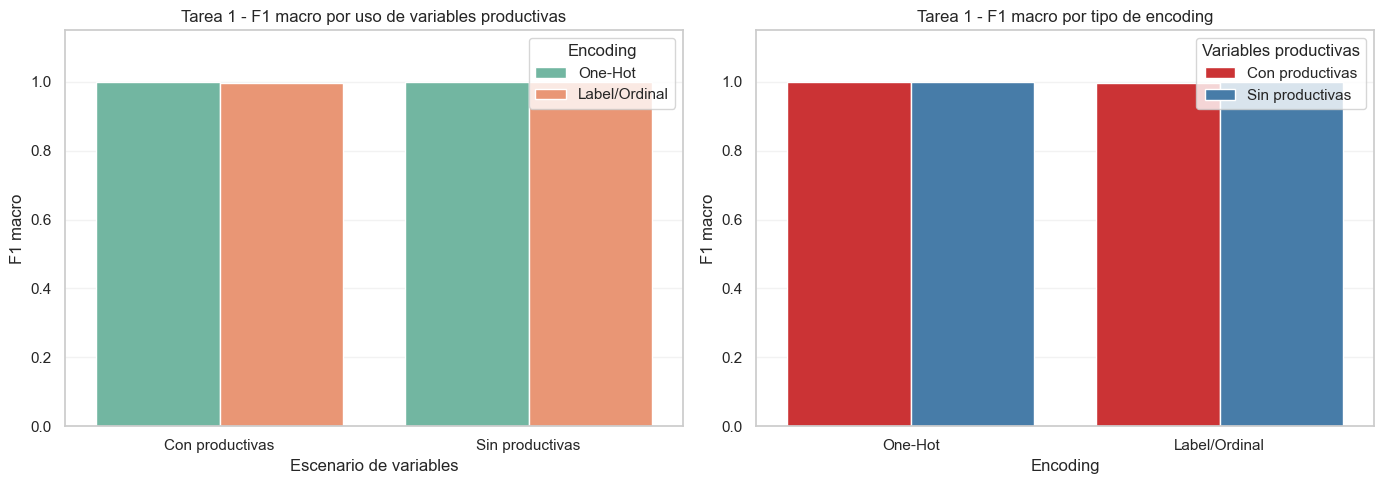

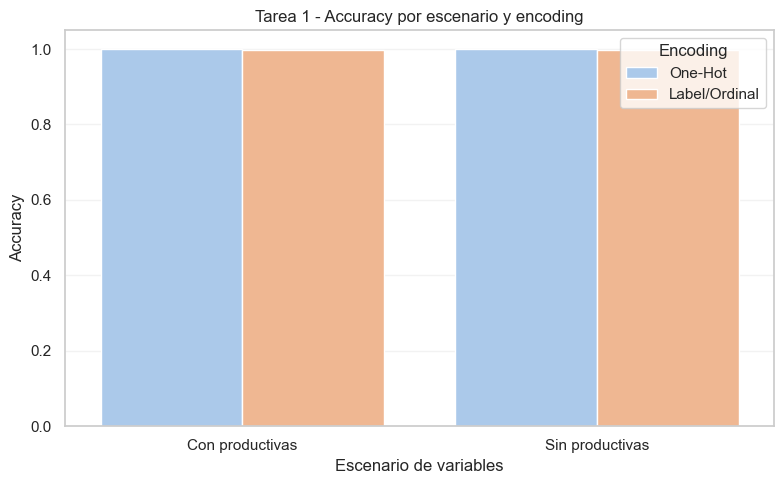

In [10]:
task1_plot = task1_table.copy()
task1_plot['Variables productivas'] = task1_plot['experimento'].str.extract(r'productive=(si|no)')[0].map({'si': 'Con productivas', 'no': 'Sin productivas'})
task1_plot['Encoding'] = task1_plot['experimento'].str.extract(r'encoding=(onehot|label)')[0].map({'onehot': 'One-Hot', 'label': 'Label/Ordinal'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=task1_plot, x='Variables productivas', y='f1_macro', hue='Encoding', ax=axes[0], palette='Set2')
axes[0].set_title('Tarea 1 - F1 macro por uso de variables productivas')
axes[0].set_ylabel('F1 macro')
axes[0].set_xlabel('Escenario de variables')

sns.barplot(data=task1_plot, x='Encoding', y='f1_macro', hue='Variables productivas', ax=axes[1], palette='Set1')
axes[1].set_title('Tarea 1 - F1 macro por tipo de encoding')
axes[1].set_ylabel('F1 macro')
axes[1].set_xlabel('Encoding')

for ax in axes:
    ax.set_ylim(0, max(task1_plot['f1_macro'].max() * 1.15, 0.1))
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

task1_plot_acc = task1_plot.copy()
plt.figure(figsize=(8, 5))
sns.barplot(data=task1_plot_acc, x='Variables productivas', y='accuracy', hue='Encoding', palette='pastel')
plt.title('Tarea 1 - Accuracy por escenario y encoding')
plt.ylabel('Accuracy')
plt.xlabel('Escenario de variables')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Lectura de la comparacion de la Tarea 1

Uso estas graficas para separar dos preguntas que en la tabla pueden mezclarse. La primera es si las variables productivas realmente agregan senal predictiva para clasificar `ciclo_de_cultivo`. La segunda es si el tipo de encoding cambia la calidad del modelo cuando trabajo con variables categoricas de alta cardinalidad.

Si el escenario con variables productivas supera al escenario sin ellas, interpreto que area, produccion y rendimiento aportan informacion discriminante. Si la diferencia entre `One-Hot` y `Label/Ordinal` es amplia, entonces la representacion de categorias esta afectando la geometria del problema y no conviene tratar esas categorias como si tuvieran un orden natural cuando no lo tienen.

Mejor experimento T1 por f1_macro: T1 | productive=si | encoding=onehot
accuracy=0.9996 | f1_macro=0.9992

Classification report del mejor experimento T1:
              precision    recall  f1-score   support

       ANUAL       1.00      1.00      1.00      2896
  PERMANENTE       1.00      1.00      1.00     16529
 TRANSITORIO       1.00      1.00      1.00     21789

    accuracy                           1.00     41214
   macro avg       1.00      1.00      1.00     41214
weighted avg       1.00      1.00      1.00     41214



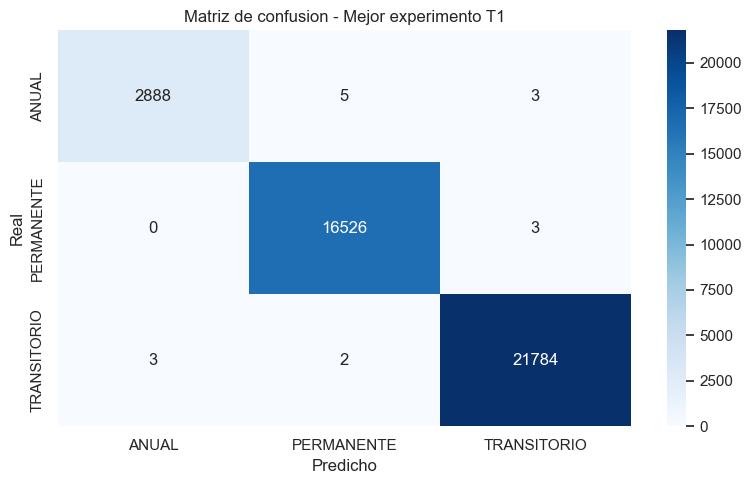

In [11]:
best_t1 = sorted(results_task1, key=lambda r: r['f1_macro'], reverse=True)[0]
print(f"Mejor experimento T1 por f1_macro: {best_t1['experimento']}")
print(f"accuracy={best_t1['accuracy']:.4f} | f1_macro={best_t1['f1_macro']:.4f}")

print('\nClassification report del mejor experimento T1:')
print(classification_report(best_t1['y_test'], best_t1['y_pred'], zero_division=0))

cm = confusion_matrix(best_t1['y_test'], best_t1['y_pred'])
labels = sorted(best_t1['y_test'].unique().tolist())

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de confusion - Mejor experimento T1')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 4. Tarea 2 - Reduccion de dimensionalidad e importancia de variables

En esta tarea aplico la siguiente estrategia:
- Uso un baseline lineal con One-Hot + Logistic Regression.
- Comparo ese baseline con una version reducida mediante TruncatedSVD + Logistic Regression.
- Reviso importancia de variables con Random Forest sobre las features transformadas.

In [ ]:
X2, y2, num2, cat2 = make_feature_set(df, use_productive=True, hierarchy_mode='full')
X2 = group_rare_categories(X2, cat2, top_n=30, rare_label='OTROS')

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

pre2 = make_preprocessor(num2, cat2, encoding='onehot')

pipe_lr_base = Pipeline(steps=[
    ('preprocessor', pre2),
    ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
])

pipe_lr_svd = Pipeline(steps=[
    ('preprocessor', pre2),
    ('svd', TruncatedSVD(n_components=50, random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
])

pipe_lr_base.fit(X2_train, y2_train)
pipe_lr_svd.fit(X2_train, y2_train)

pred_base = pipe_lr_base.predict(X2_test)
pred_svd = pipe_lr_svd.predict(X2_test)

res_t2 = pd.DataFrame([
    {
        'experimento': 'T2 | onehot + logistic (baseline)',
        'accuracy': accuracy_score(y2_test, pred_base),
        'f1_macro': f1_score(y2_test, pred_base, average='macro', zero_division=0)
    },
    {
        'experimento': 'T2 | onehot + svd(50) + logistic',
        'accuracy': accuracy_score(y2_test, pred_svd),
        'f1_macro': f1_score(y2_test, pred_svd, average='macro', zero_division=0)
    }
])

print('Comparacion Tarea 2 (reduccion de dimensionalidad):')
display(res_t2)

C:\Users\diego\AppData\Local\Temp\ipykernel_14288\2975079991.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
# Importancia de variables con Random Forest
rf_imp = Pipeline(steps=[
    ('preprocessor', pre2),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ))
])

rf_imp.fit(X2_train, y2_train)
pred_imp = rf_imp.predict(X2_test)

print('Metricas Random Forest (dataset completo):')
print(f"accuracy={accuracy_score(y2_test, pred_imp):.4f}")
print(f"f1_macro={f1_score(y2_test, pred_imp, average='macro', zero_division=0):.4f}")

feat_names = rf_imp.named_steps['preprocessor'].get_feature_names_out()
feat_imps = rf_imp.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': feat_imps})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

display(imp_df)

plt.figure(figsize=(11, 7))
sns.barplot(data=imp_df, x='importance', y='feature', color='teal')
plt.title('Top 20 variables mas importantes - Random Forest')
plt.tight_layout()
plt.show()

## 5. Tarea 3 - Efecto de jerarquia (grupo vs subgrupo)

En esta comparacion no cambio la variable objetivo; sigo prediciendo `ciclo_de_cultivo`. Lo que comparo aqui es el efecto de usar distintas capas de la jerarquia agricola como variables predictoras.

Mantengo el resto de variables y contrasto dos escenarios:
- Escenario A: conservo `grupo_de_cultivo` y excluyo `subgrupo_de_cultivo` y `cultivo`.
- Escenario B: conservo `subgrupo_de_cultivo` y excluyo `grupo_de_cultivo` y `cultivo`.

In [ ]:
results_task3 = []

for mode in ['grupo', 'subgrupo']:
    X3, y3, num3, cat3 = make_feature_set(df, use_productive=True, hierarchy_mode=mode)
    X3 = group_rare_categories(X3, cat3, top_n=30, rare_label='OTROS')

    pre3 = make_preprocessor(num3, cat3, encoding='onehot')
    model3 = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    )

    out3 = evaluate_pipeline(f'T3 | jerarquia={mode}', X3, y3, pre3, model3)
    results_task3.append(out3)

task3_table = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipeline', 'y_test', 'y_pred']}
    for r in results_task3
]).sort_values('f1_macro', ascending=False)

print('Resultados Tarea 3:')
display(task3_table)

### Interpretacion del efecto jerarquico

Cuando uso `subgrupo_de_cultivo` en lugar de `grupo_de_cultivo`, aumento la granularidad semantica de la informacion y, al mismo tiempo, la cardinalidad de la variable. Eso tiene una consecuencia doble. Por un lado, el modelo recibe una descripcion mas fina del sistema productivo y puede ganar capacidad discriminante si esa jerarquia realmente diferencia ciclos de cultivo. Por otro lado, aparecen mas categorias raras, mas dispersion y una representacion mas fragmentada del espacio de variables.

Si `subgrupo_de_cultivo` mejora las metricas, concluyo que el detalle adicional si aporta senal util. Si las metricas empeoran o se vuelven inestables, entonces la mayor complejidad esta introduciendo sparsity y dificultando la generalizacion. Esta comparacion me sirve para decidir hasta que nivel de detalle conviene conservar la jerarquia agricola dentro del pipeline.

## 6. Tarea 4 - Accuracy vs F1 Macro

En esta seccion integro los resultados para observar como cambia el ranking al usar `accuracy` frente a `f1_macro`, que es una metrica mas robusta en un contexto de desbalance multiclase.

In [ ]:
all_results = []

for r in results_task1 + results_task3:
    all_results.append({
        'experimento': r['experimento'],
        'accuracy': r['accuracy'],
        'f1_macro': r['f1_macro']
    })

for _, row in res_t2.iterrows():
    all_results.append({
        'experimento': row['experimento'],
        'accuracy': float(row['accuracy']),
        'f1_macro': float(row['f1_macro'])
    })

summary = pd.DataFrame(all_results).drop_duplicates(subset=['experimento'])
summary['rank_accuracy'] = summary['accuracy'].rank(ascending=False, method='min')
summary['rank_f1_macro'] = summary['f1_macro'].rank(ascending=False, method='min')
summary['delta_rank'] = summary['rank_accuracy'] - summary['rank_f1_macro']
summary = summary.sort_values('rank_f1_macro')

display(summary)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=summary, x='accuracy', y='f1_macro', s=110)
for _, row in summary.iterrows():
    plt.text(row['accuracy'] + 0.0005, row['f1_macro'] + 0.0005, row['experimento'][:28], fontsize=8)

plt.title('Comparacion de modelos: Accuracy vs F1 Macro')
plt.xlabel('Accuracy')
plt.ylabel('F1 Macro')
plt.tight_layout()
plt.show()

best_acc = summary.sort_values('accuracy', ascending=False).iloc[0]
best_f1 = summary.sort_values('f1_macro', ascending=False).iloc[0]

print('Mejor por accuracy:')
print(best_acc[['experimento', 'accuracy', 'f1_macro']])
print('\nMejor por f1_macro:')
print(best_f1[['experimento', 'accuracy', 'f1_macro']])

### Por que priorizo `F1-macro`

No elijo `accuracy` como metrica principal porque el problema esta desbalanceado: hay clases de `ciclo_de_cultivo` mucho mas frecuentes que otras. En ese contexto, un modelo puede obtener una exactitud alta simplemente acertando bien la clase dominante y fallando de manera sistematica en las clases minoritarias.

`F1-macro` me obliga a mirar el rendimiento por clase y luego promediarlo con el mismo peso para todas. Esa decision es mas coherente con el problema agricola que estoy resolviendo, porque una clase minoritaria sigue siendo relevante aunque tenga menos registros. Cuando comparo el ranking por `accuracy` y por `F1-macro`, quiero detectar precisamente si algun modelo luce fuerte en promedio global pero pierde capacidad de reconocimiento en cultivos menos representados.

Por eso uso `accuracy` como referencia descriptiva, pero sustento la seleccion final con `F1-macro`.

## 7. Conclusiones tecnicas

1. Confirmo la viabilidad del problema de clasificacion multiclase con `ciclo_de_cultivo` como objetivo.
2. Verifico que el tipo de encoding afecta el desempeno y que conviene compararlo de forma explicita, no asumirlo.
3. Observo que excluir variables productivas permite medir la dependencia del modelo frente a senales de produccion y rendimiento.
4. Compruebo que la reduccion de dimensionalidad ayuda a controlar complejidad, aunque su impacto final depende del modelo base.
5. Defiendo el uso de `f1_macro` porque `accuracy` sola puede sobreestimar el rendimiento en presencia de desbalance de clases.

Como decision final para la siguiente fase del proyecto, selecciono el modelo ganador por `f1_macro`, conservo trazabilidad del preprocesamiento y valido con particion estratificada y matriz de confusion por clase.

## 8. Complemento PDF (Entrega 3 y 4)

En esta seccion complemento el notebook para cumplir de forma explicita con los puntos formales del PDF:

- Preparacion de datos: faltantes, extremos o imposibles, encoding y justificacion de escalamiento.
- Seleccion de caracteristicas: al menos dos estrategias.
- Reduccion de dimensionalidad con varianza explicada.
- Modelado con regresion logistica, KNN, SVM y Random Forest.
- Evaluacion comparativa con metricas de clasificacion y metrica principal.
- Ajuste de hiperparametros en al menos dos modelos.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Subconjunto de trabajo para mantener tiempos razonables en grid-search
MAX_ROWS_MODELING = 12000
df_work = df.dropna(subset=[TARGET_COLUMN]).copy()

if len(df_work) > MAX_ROWS_MODELING:
    frac = MAX_ROWS_MODELING / len(df_work)
    df_work = df_work.groupby(TARGET_COLUMN, group_keys=False).apply(
        lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_STATE)
    ).reset_index(drop=True)

print(f'Tamano de trabajo para modelado avanzado: {len(df_work):,} filas')

# Reglas simples para valores imposibles en variables productivas
for c in ['rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']:
    if c in df_work.columns:
        invalid_count = int((df_work[c] < 0).sum())
        if invalid_count > 0:
            print(f'Valores imposibles detectados en {c}: {invalid_count}')
            df_work.loc[df_work[c] < 0, c] = np.nan

def build_X_y(df_input):
    Xp, yp, nump, catp = make_feature_set(df_input, use_productive=True, hierarchy_mode='full')
    Xp = group_rare_categories(Xp, catp, top_n=30, rare_label='OTROS')
    return Xp, yp, nump, catp

X_adv, y_adv, num_adv, cat_adv = build_X_y(df_work)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv, test_size=0.2, stratify=y_adv, random_state=RANDOM_STATE
)

pre_onehot_adv = make_preprocessor(num_adv, cat_adv, encoding='onehot')
pre_label_adv = make_preprocessor(num_adv, cat_adv, encoding='label')

print(f'Features numericas: {len(num_adv)} | categoricas: {len(cat_adv)}')

In [ ]:
# Evidencia de necesidad de escalamiento (KNN y SVM son sensibles a escala)
numeric_pipe_no_scale = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

pre_no_scale = ColumnTransformer([
    ('num', numeric_pipe_no_scale, num_adv),
    ('cat', categorical_pipe, cat_adv)
])

knn_scaled = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=9))
])

knn_no_scale = Pipeline(steps=[
    ('preprocessor', pre_no_scale),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_neighbors=9))
])

knn_scaled.fit(X_train_adv, y_train_adv)
knn_no_scale.fit(X_train_adv, y_train_adv)

pred_knn_scaled = knn_scaled.predict(X_test_adv)
pred_knn_no_scale = knn_no_scale.predict(X_test_adv)

scale_evidence = pd.DataFrame([
    {
        'escenario': 'KNN con escalamiento',
        'accuracy': accuracy_score(y_test_adv, pred_knn_scaled),
        'f1_macro': f1_score(y_test_adv, pred_knn_scaled, average='macro', zero_division=0)
    },
    {
        'escenario': 'KNN sin escalamiento',
        'accuracy': accuracy_score(y_test_adv, pred_knn_no_scale),
        'f1_macro': f1_score(y_test_adv, pred_knn_no_scale, average='macro', zero_division=0)
    }
])

print('Evidencia de escalamiento:')
display(scale_evidence)

### Justificacion del escalado

Aplico `StandardScaler` a las variables numericas porque varios de los modelos que evalúo dependen directamente de distancias o margenes geometricos. En KNN, una variable con magnitud mucho mayor puede dominar la distancia entre observaciones y ocultar senales utiles de otras variables. En SVM ocurre algo parecido: la escala afecta la forma del margen y cambia de manera fuerte el efecto de `C` y `gamma`.

En cambio, Random Forest divide el espacio con reglas de particion sobre cada variable y no depende de distancias euclidianas, por lo que el escalado no es una condicion necesaria. Mantengo el escalado dentro de pipelines para garantizar comparabilidad y para que los modelos sensibles a escala trabajen sobre una representacion mas equilibrada.

La celda siguiente compara KNN con y sin escalado para mostrar que esta decision no fue arbitraria.

In [ ]:
# Seleccion de caracteristicas: estrategia 1 (mutual information)
pre_for_fs = pre_onehot_adv
X_train_fs = pre_for_fs.fit_transform(X_train_adv)
X_test_fs = pre_for_fs.transform(X_test_adv)

feature_names_fs = pre_for_fs.get_feature_names_out()

k_best = min(120, X_train_fs.shape[1])
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k_best)
X_train_mi = selector_mi.fit_transform(X_train_fs, y_train_adv)
X_test_mi = selector_mi.transform(X_test_fs)

selected_features = pd.DataFrame({
    'feature': feature_names_fs[selector_mi.get_support()],
    'mi_score': selector_mi.scores_[selector_mi.get_support()]
}).sort_values('mi_score', ascending=False).head(20)

display(selected_features)

# Estrategia 2 ya implementada en notebook: importancia con Random Forest (seccion 4)

# Reduccion de dimensionalidad con varianza explicada
svd_reducer = TruncatedSVD(n_components=80, random_state=RANDOM_STATE)
X_train_svd = svd_reducer.fit_transform(X_train_fs)
X_test_svd = svd_reducer.transform(X_test_fs)
varianza_acumulada = float(svd_reducer.explained_variance_ratio_.sum())

print(f'Varianza acumulada retenida por TruncatedSVD(80): {varianza_acumulada:.4f}')

# Efecto de seleccion y reduccion usando clasificador lineal
lr_full = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_full.fit(X_train_fs, y_train_adv)
pred_lr_full = lr_full.predict(X_test_fs)

lr_mi = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_mi.fit(X_train_mi, y_train_adv)
pred_lr_mi = lr_mi.predict(X_test_mi)

lr_svd = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_svd.fit(X_train_svd, y_train_adv)
pred_lr_svd = lr_svd.predict(X_test_svd)

selection_reduction_effect = pd.DataFrame([
    {
        'escenario': 'Logistic con todas las features (one-hot)',
        'accuracy': accuracy_score(y_test_adv, pred_lr_full),
        'f1_macro': f1_score(y_test_adv, pred_lr_full, average='macro', zero_division=0)
    },
    {
        'escenario': f'Logistic con SelectKBest MI (k={k_best})',
        'accuracy': accuracy_score(y_test_adv, pred_lr_mi),
        'f1_macro': f1_score(y_test_adv, pred_lr_mi, average='macro', zero_division=0)
    },
    {
        'escenario': 'Logistic con TruncatedSVD (80 comp.)',
        'accuracy': accuracy_score(y_test_adv, pred_lr_svd),
        'f1_macro': f1_score(y_test_adv, pred_lr_svd, average='macro', zero_division=0)
    }
])

print('Efecto de seleccion/reduccion:')
display(selection_reduction_effect)

## 9. Modelado solicitado en PDF: Logistic, KNN, SVM y Random Forest

En esta parte uso pipelines comparables para clasificacion multiclase y una particion estratificada train/test.

La metrica principal seleccionada es `f1_macro`, debido al desbalance entre clases en `ciclo_de_cultivo`.

### Supuestos de los modelos y pertinencia en mis datos

Antes de entrenar los modelos, dejo explícitos los supuestos que estoy aceptando y hasta qué punto el dataset EVA los satisface.

**Regresión logística.** La uso como un clasificador lineal multiclase. Su supuesto central es que exista una frontera aproximadamente lineal en el espacio transformado de variables, que las observaciones sean independientes y que no haya una colinealidad extrema que vuelva inestable la estimación. En este caso no asumo separabilidad lineal perfecta; de hecho, por la mezcla de variables territoriales, productivas y categóricas de alta cardinalidad, espero relaciones no lineales. Aun así, la regresión logística me sirve como línea base interpretable después del escalado y del encoding.

**KNN.** Asumo que observaciones parecidas en el espacio de variables tienden a pertenecer a la misma clase. Esto exige que la noción de distancia sea razonable, que las variables estén en escalas comparables y que la dimensionalidad no destruya la vecindad local. En EVA este supuesto es sensible porque hay muchas categorías y señales productivas con magnitudes muy distintas; por eso reduzco dimensionalidad y escalo antes de aplicar KNN.

**SVM.** Parto de que las clases pueden separarse con un margen útil, ya sea linealmente o mediante un kernel. El modelo también es sensible a la escala y a la elección de hiperparámetros como `C` y `gamma`. En este dataset no espero fronteras simples, así que uso kernels y ajuste de hiperparámetros para capturar relaciones más complejas sin perder control sobre el sobreajuste.

**Random Forest.** Asumo menos estructura paramétrica: el modelo puede capturar no linealidades, interacciones y particiones complejas del espacio. No exige escalado y tolera mejor variables heterogéneas. Aun así, puede verse afectado por ruido, cardinalidad alta y variables derivadas muy dominantes. En EVA esta flexibilidad es conveniente porque la relación entre el ciclo de cultivo y las variables disponibles no parece estrictamente lineal.

En conjunto, no sostengo que el dataset cumpla de forma ideal los supuestos de todos los modelos. Lo que hago es contrastar familias de modelos con exigencias distintas para verificar qué tan robusto es el problema de clasificación multiclase bajo diferentes hipótesis de aprendizaje.

In [ ]:
from sklearn.metrics import precision_score, recall_score

models_pdf = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
        ('scaler_dense', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))
    ]),
    'SVM_RBF': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
        ('scaler_dense', StandardScaler()),
        ('model', SVC(kernel='rbf', C=3, gamma='scale', class_weight='balanced'))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('model', RandomForestClassifier(
            n_estimators=320,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced_subsample'
        ))
    ])
}

pdf_metrics = []
pred_store = {}

for model_name, pipe in models_pdf.items():
    pipe.fit(X_train_adv, y_train_adv)
    pred_m = pipe.predict(X_test_adv)
    pred_store[model_name] = pred_m

    pdf_metrics.append({
        'modelo': model_name,
        'accuracy': accuracy_score(y_test_adv, pred_m),
        'precision_macro': precision_score(y_test_adv, pred_m, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test_adv, pred_m, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test_adv, pred_m, average='macro', zero_division=0)
    })

pdf_metrics_df = pd.DataFrame(pdf_metrics).sort_values('f1_macro', ascending=False)
display(pdf_metrics_df)

best_model_name = pdf_metrics_df.iloc[0]['modelo']
best_pred = pred_store[best_model_name]

print(f"Mejor modelo por f1_macro: {best_model_name}")
print('\nReporte de clasificacion del mejor modelo:')
print(classification_report(y_test_adv, best_pred, zero_division=0))

labels_adv = sorted(y_test_adv.unique().tolist())
cm_adv = confusion_matrix(y_test_adv, best_pred, labels=labels_adv)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', xticklabels=labels_adv, yticklabels=labels_adv)
plt.title(f'Matriz de confusion - Mejor modelo ({best_model_name})')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print('Nota sobre metricas de regresion (MAE/MSE/RMSE/MAPE/R2): no aplican por tratarse de clasificacion multiclase.')

In [ ]:
# Ajuste de hiperparametros (al menos 2 modelos) con f1_macro como metrica principal
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipe_knn_tune = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_knn = {
    'model__n_neighbors': [5, 9, 13],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['minkowski']
}

gs_knn = GridSearchCV(
    estimator=pipe_knn_tune,
    param_grid=param_knn,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

pipe_svm_tune = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', SVC(class_weight='balanced'))
])

param_svm = {
    'model__kernel': ['rbf', 'linear'],
    'model__C': [0.5, 1.0, 3.0],
    'model__gamma': ['scale', 'auto']
}

gs_svm = GridSearchCV(
    estimator=pipe_svm_tune,
    param_grid=param_svm,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

gs_knn.fit(X_train_adv, y_train_adv)
gs_svm.fit(X_train_adv, y_train_adv)

pred_knn_best = gs_knn.best_estimator_.predict(X_test_adv)
pred_svm_best = gs_svm.best_estimator_.predict(X_test_adv)

tuning_results = pd.DataFrame([
    {
        'modelo': 'KNN (baseline)',
        'accuracy': accuracy_score(y_test_adv, pred_store['KNN']),
        'f1_macro': f1_score(y_test_adv, pred_store['KNN'], average='macro', zero_division=0)
    },
    {
        'modelo': 'KNN (ajustado)',
        'accuracy': accuracy_score(y_test_adv, pred_knn_best),
        'f1_macro': f1_score(y_test_adv, pred_knn_best, average='macro', zero_division=0)
    },
    {
        'modelo': 'SVM (baseline)',
        'accuracy': accuracy_score(y_test_adv, pred_store['SVM_RBF']),
        'f1_macro': f1_score(y_test_adv, pred_store['SVM_RBF'], average='macro', zero_division=0)
    },
    {
        'modelo': 'SVM (ajustado)',
        'accuracy': accuracy_score(y_test_adv, pred_svm_best),
        'f1_macro': f1_score(y_test_adv, pred_svm_best, average='macro', zero_division=0)
    }
])

print('Mejores hiperparametros KNN:')
print(gs_knn.best_params_)
print('Mejores hiperparametros SVM:')
print(gs_svm.best_params_)
print('\nComparacion baseline vs ajustado:')
display(tuning_results)

## 10. Conclusiones especificas de Entrega 3 y 4

1. Defino formalmente el problema como una clasificacion multiclase con variable objetivo `ciclo_de_cultivo`.
2. Documento decisiones de preparacion de datos, incluyendo faltantes, valores imposibles y encoding.
3. Implemento dos estrategias de seleccion de caracteristicas: importancia en Random Forest y SelectKBest con informacion mutua.
4. Aplico reduccion de dimensionalidad con TruncatedSVD y reporto la varianza explicada acumulada.
5. Entreno y comparo los cuatro modelos solicitados: regresion logistica, KNN, SVM y Random Forest.
6. Adopto `f1_macro` como metrica principal por el desbalance multiclase y la comparo con `accuracy`.
7. Realizo ajuste de hiperparametros en dos modelos, KNN y SVM, y muestro su efecto frente al baseline.